# 🔍 CLIP on CIFAR-10 — Visual Walkthrough
## How does a model with *no task-specific training* get 86% accuracy?

**CLIP (Contrastive Language–Image Pre-training)** by OpenAI learns to match images to text descriptions.  
At test time, we never fine-tune it — we just ask: *"Which text label has the highest cosine similarity to this image?"*

This notebook walks you through every step visually.

## Section 1 — Imports

In [1]:
import sys, os
import torch
import open_clip
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from torchvision import datasets
from PIL import Image
import random
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("PyTorch:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")
print("open_clip:", open_clip.__version__)

/home/hpc/v123be/v123be33/.conda/envs/vlm_edge/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.5.1+cu121
Device: cpu
open_clip: 3.2.0


## Section 2 — Load CLIP Model

We load `ViT-B/32` — a Vision Transformer that splits an image into 32×32 patches and processes them.  
The model was pre-trained on 400 million (image, caption) pairs from the internet.  
We use **no fine-tuning** on CIFAR-10 — this is called **zero-shot classification**.

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
tokenizer = open_clip.get_tokenizer("ViT-B-32")
preprocess = preprocess_val
model = model.to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model: ViT-B/32  |  Parameters: {total_params:.1f}M  |  Device: {device}")
print("Pretrained on: ~400M (image, text) pairs from the internet")
print("Task: zero-shot classification — no CIFAR-10 training at all!")

Model: ViT-B/32  |  Parameters: 151.3M  |  Device: cpu
Pretrained on: ~400M (image, text) pairs from the internet
Task: zero-shot classification — no CIFAR-10 training at all!


## Section 3 — Load CIFAR-10 and Sample Random Images

CIFAR-10 has **10,000 test images** across 10 classes (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck).  
Each image is tiny: **32×32 pixels**. CLIP upscales them to 224×224 — so it's working harder than usual!

Files already downloaded and verified
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Test set size: 10000 images

Sampled 20 images  |  2 per class


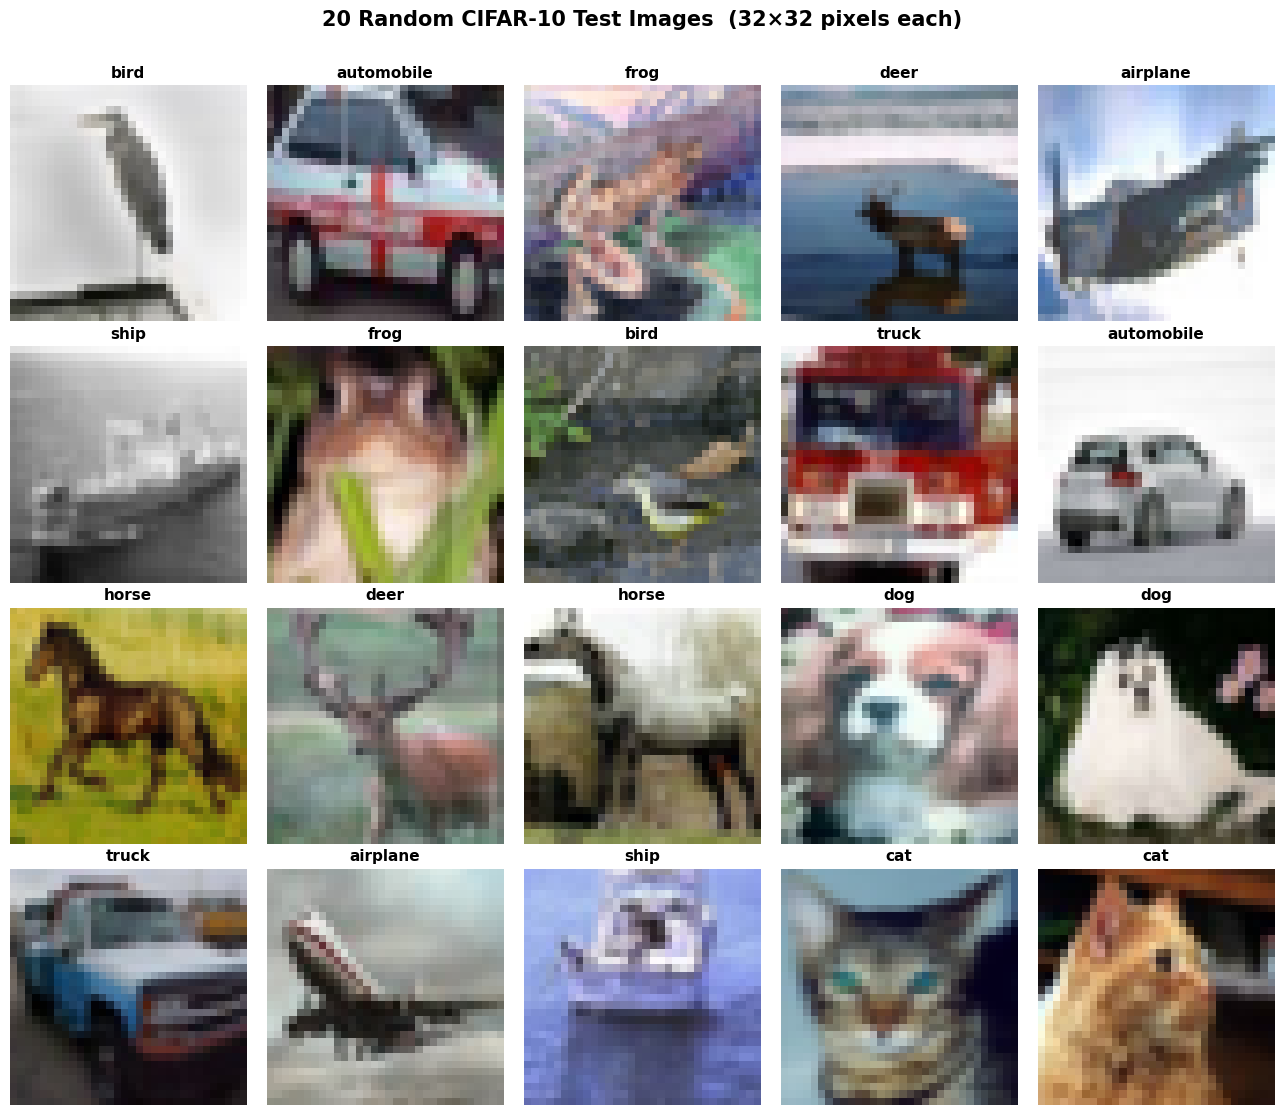

In [3]:
# Load raw CIFAR-10 (no transform yet — we want PIL images for display)
raw_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=None)
class_names = raw_dataset.classes
print("Classes:", class_names)
print(f"Test set size: {len(raw_dataset)} images")

# Sample 20 random images (ensuring 2 per class for variety)
indices_per_class = {c: [] for c in range(10)}
for idx, (_, label) in enumerate(raw_dataset):
    indices_per_class[label].append(idx)

sampled_indices = []
for c in range(10):
    sampled_indices.extend(random.sample(indices_per_class[c], 2))
random.shuffle(sampled_indices)

# Pull out PIL images + labels
sample_images = []  # PIL images (original 32x32)
sample_labels = []  # int class indices
for idx in sampled_indices:
    img, label = raw_dataset[idx]
    sample_images.append(img)
    sample_labels.append(label)

print(f"\nSampled {len(sample_images)} images  |  2 per class")

# Display the 20 sampled images in a 4×5 grid
fig, axes = plt.subplots(4, 5, figsize=(13, 11))
fig.suptitle("20 Random CIFAR-10 Test Images  (32×32 pixels each)", fontsize=15, fontweight='bold', y=1.01)
for ax, img, label in zip(axes.flat, sample_images, sample_labels):
    ax.imshow(img)
    ax.set_title(class_names[label], fontsize=11, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Section 4 — Prepare Text Prompts for CLIP

Instead of feeding CLIP just a bare label like `"cat"`, we use a sentence template.  
The prompt `"a photo of a cat"` is much closer to the kind of image captions CLIP was trained on.  
This small trick significantly boosts accuracy!

In [4]:
template = "a photo of a {}"
text_prompts = [template.format(c) for c in class_names]

print("Text prompts fed into CLIP's text encoder:\n")
for i, prompt in enumerate(text_prompts):
    print(f"  [{i:2d}]  {prompt}")

# Tokenize — converts text to integer token IDs (like how GPT works)
text_tokens = tokenizer(text_prompts).to(device)
print(f"\nToken tensor shape: {text_tokens.shape}  (10 prompts × 77 max tokens)")

Text prompts fed into CLIP's text encoder:

  [ 0]  a photo of a airplane
  [ 1]  a photo of a automobile
  [ 2]  a photo of a bird
  [ 3]  a photo of a cat
  [ 4]  a photo of a deer
  [ 5]  a photo of a dog
  [ 6]  a photo of a frog
  [ 7]  a photo of a horse
  [ 8]  a photo of a ship
  [ 9]  a photo of a truck

Token tensor shape: torch.Size([10, 77])  (10 prompts × 77 max tokens)


## Section 5 — Encode Images & Text into Embedding Space

CLIP maps both images and text into the **same 512-dimensional vector space**.  
After encoding, we normalize each vector to length 1 (L2 norm).  
This means dot-product = cosine similarity — a score from -1 to +1 measuring how "aligned" they are.

```
Image  ──► Image Encoder (ViT-B/32) ──►  512-dim vector  ─┐
                                                            ├──► cosine similarity
Text   ──► Text Encoder  (Transformer) ──►  512-dim vector  ─┘
```

In [5]:
with torch.no_grad():
    # --- Text embeddings (encode all 10 prompts) ---
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)  # L2 normalize

    # --- Image embeddings (encode our 20 sampled images) ---
    preprocessed = torch.stack([preprocess(img) for img in sample_images]).to(device)
    image_features = model.encode_image(preprocessed)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)  # L2 normalize

print(f"Image feature matrix shape : {image_features.shape}  (20 images  × 512 dims)")
print(f"Text  feature matrix shape : {text_features.shape}  (10 labels  × 512 dims)")
print()
print("Both live in the same 512-dimensional space.")
print("Now we just compute dot products to get cosine similarities!")

Image feature matrix shape : torch.Size([20, 512])  (20 images  × 512 dims)
Text  feature matrix shape : torch.Size([10, 512])  (10 labels  × 512 dims)

Both live in the same 512-dimensional space.
Now we just compute dot products to get cosine similarities!


## Section 6 — Compute Cosine Similarity Scores

We compute a **20 × 10 matrix**: one row per image, one column per label.  
Each cell = how strongly that image "matches" that text label, on a scale roughly 0→1.  
The predicted class = column with the highest score in each row.

In [6]:
# cosine sim matrix: shape [20 images, 10 labels]  (vectors already L2 normalized)
sim_matrix = (image_features @ text_features.T).cpu().numpy()

# Predictions
preds = sim_matrix.argmax(axis=1)
true_labels = np.array(sample_labels)
correct_mask = preds == true_labels

print("Cosine Similarity Matrix  (rows = images, cols = class labels)")
print("="*70)
header = f"{'':16s}" + "".join(f"{c:8s}" for c in class_names)
print(header)
print("-"*70)
for i, (row, true, pred) in enumerate(zip(sim_matrix, true_labels, preds)):
    tick = "✓" if pred == true else "✗"
    row_str = f"Img {i:02d} ({class_names[true][:6]:6s}){tick} " + \
              "".join(f"{'>>'+f'{v:.2f}':<8s}" if j==pred else f"{v:8.2f}" for j, v in enumerate(row))
    print(row_str)

sample_acc = correct_mask.mean() * 100
print(f"\nSample accuracy: {correct_mask.sum()}/{len(correct_mask)} = {sample_acc:.1f}%")

Cosine Similarity Matrix  (rows = images, cols = class labels)
                airplaneautomobilebird    cat     deer    dog     frog    horse   ship    truck   
----------------------------------------------------------------------
Img 00 (bird  )✓     0.22    0.21>>0.29      0.22    0.21    0.22    0.21    0.21    0.21    0.21
Img 01 (automo)✓     0.17>>0.24      0.18    0.18    0.18    0.18    0.17    0.19    0.20    0.23
Img 02 (frog  )✗     0.22    0.21    0.23    0.23>>0.24      0.23    0.23    0.22    0.24    0.22
Img 03 (deer  )✓     0.22    0.21    0.24    0.23>>0.30      0.26    0.23    0.25    0.23    0.22
Img 04 (airpla)✗     0.26    0.23    0.23    0.21    0.23    0.22    0.22    0.22>>0.27      0.25
Img 05 (ship  )✓     0.21    0.22    0.22    0.20    0.21    0.21    0.19    0.22>>0.29      0.23
Img 06 (frog  )✓     0.21    0.21    0.25    0.22    0.25    0.23>>0.28      0.22    0.20    0.21
Img 07 (bird  )✓     0.22    0.22>>0.28      0.22    0.23    0.23    0.27    0.22

## Section 7 — Each Image: What Did CLIP Think?

For every image we show:
- The actual photo
- A horizontal bar chart of all 10 cosine similarity scores
- **Green bar** = model's top prediction
- **Blue bar** = correct label (if different from prediction)
- **Red bar** = wrong prediction (when the model made a mistake)

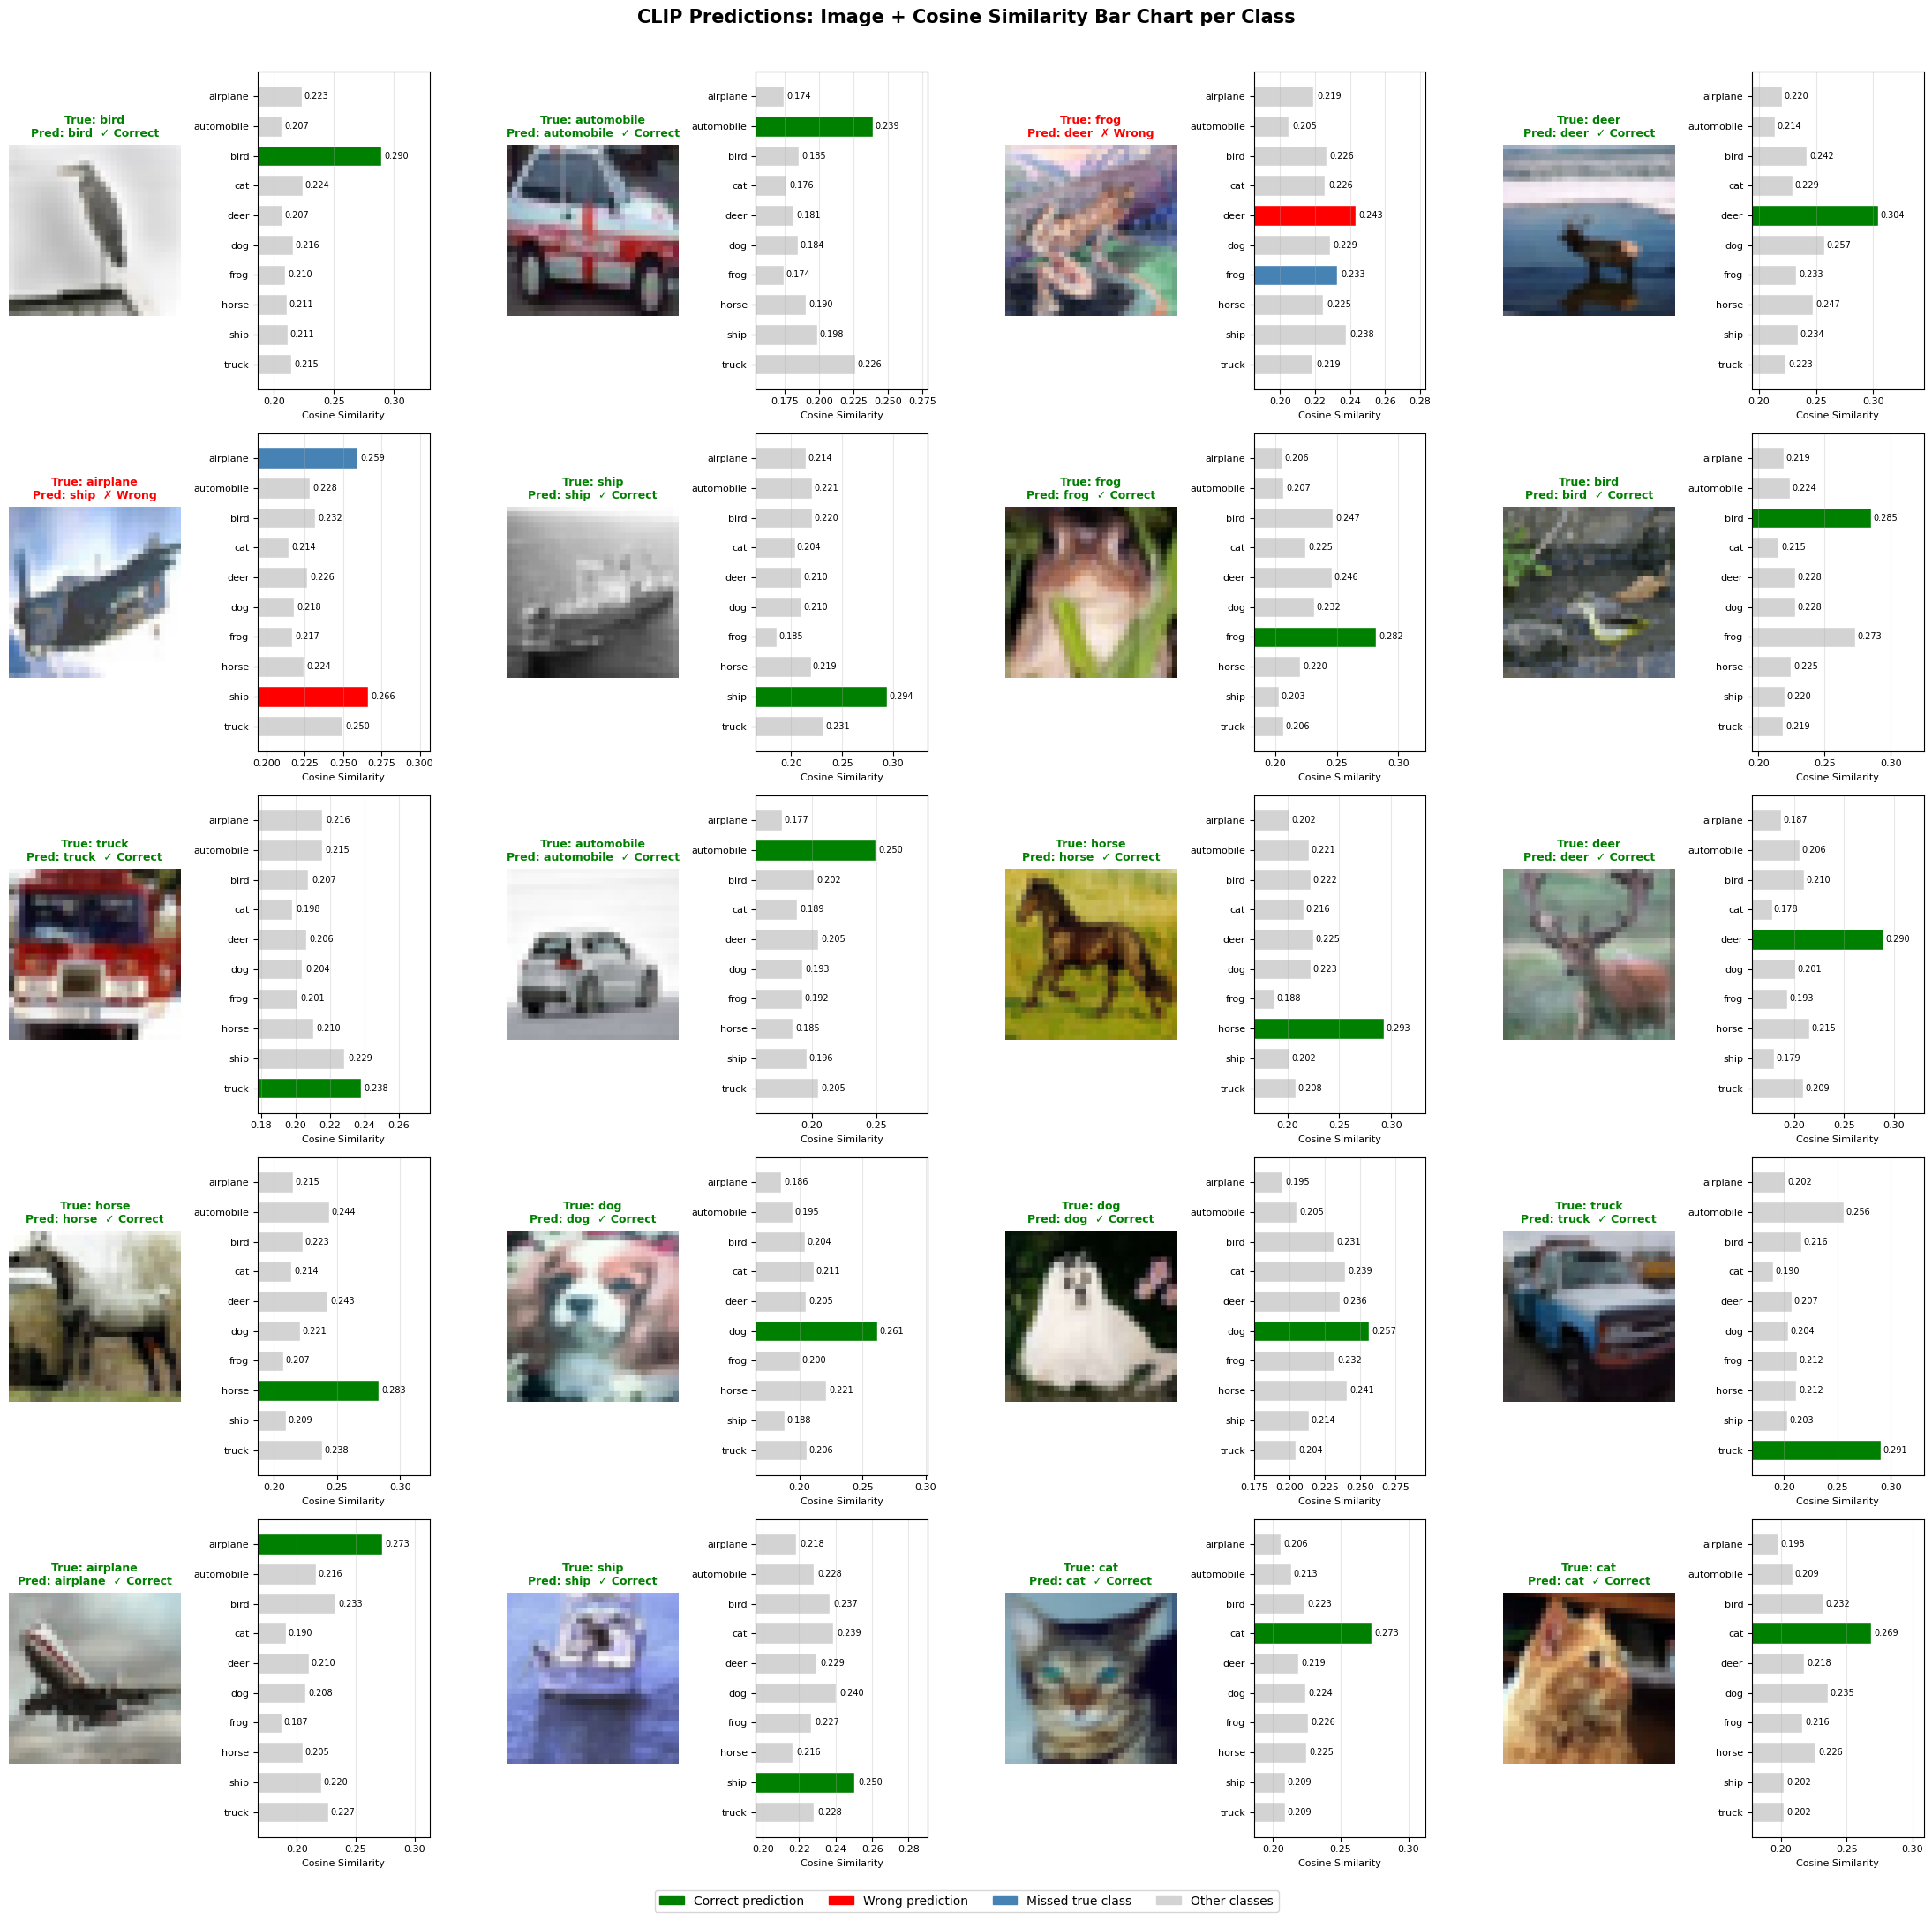

In [7]:
n = len(sample_images)
cols = 4  # 4 images per row
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols * 2, figsize=(22, rows * 4.2))
fig.suptitle("CLIP Predictions: Image + Cosine Similarity Bar Chart per Class",
             fontsize=15, fontweight='bold', y=1.01)

for i in range(rows * cols):
    img_ax  = axes[i // cols][( i % cols) * 2]
    bar_ax  = axes[i // cols][(i % cols) * 2 + 1]

    if i >= n:
        img_ax.axis('off')
        bar_ax.axis('off')
        continue

    img   = sample_images[i]
    true  = true_labels[i]
    pred  = preds[i]
    scores = sim_matrix[i]

    # ── Image panel ──────────────────────────────────────────────
    img_ax.imshow(img.resize((128, 128), Image.NEAREST))
    status = "✓ Correct" if pred == true else "✗ Wrong"
    color  = "green" if pred == true else "red"
    img_ax.set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}  {status}",
                     fontsize=9, color=color, fontweight='bold')
    img_ax.axis('off')

    # ── Bar chart panel ───────────────────────────────────────────
    bar_colors = []
    for j in range(10):
        if j == pred and j == true:
            bar_colors.append("green")        # correct prediction
        elif j == pred and j != true:
            bar_colors.append("red")          # wrong prediction
        elif j == true and j != pred:
            bar_colors.append("steelblue")    # missed correct class
        else:
            bar_colors.append("lightgray")

    bars = bar_ax.barh(class_names, scores, color=bar_colors, edgecolor='white', height=0.7)
    bar_ax.set_xlim(scores.min() - 0.02, scores.max() + 0.04)
    bar_ax.set_xlabel("Cosine Similarity", fontsize=8)
    bar_ax.tick_params(labelsize=8)

    # Annotate top bar value
    for bar, val in zip(bars, scores):
        bar_ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                    f"{val:.3f}", va='center', fontsize=7)

    bar_ax.invert_yaxis()
    bar_ax.grid(axis='x', alpha=0.3)

# Legend
patches = [
    mpatches.Patch(color='green',     label='Correct prediction'),
    mpatches.Patch(color='red',       label='Wrong prediction'),
    mpatches.Patch(color='steelblue', label='Missed true class'),
    mpatches.Patch(color='lightgray', label='Other classes'),
]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02), frameon=True)

plt.tight_layout()
plt.show()

## Section 8 — Accuracy on Our Sample + Confusion Matrix

The confusion matrix shows which classes CLIP confuses most.  
Rows = true label, Columns = predicted label.  
A perfect model would have all values on the diagonal.

Sample accuracy : 90.0%  (18/20 correct)
Full test set   : 86.2%  (from baseline_fp32.json)



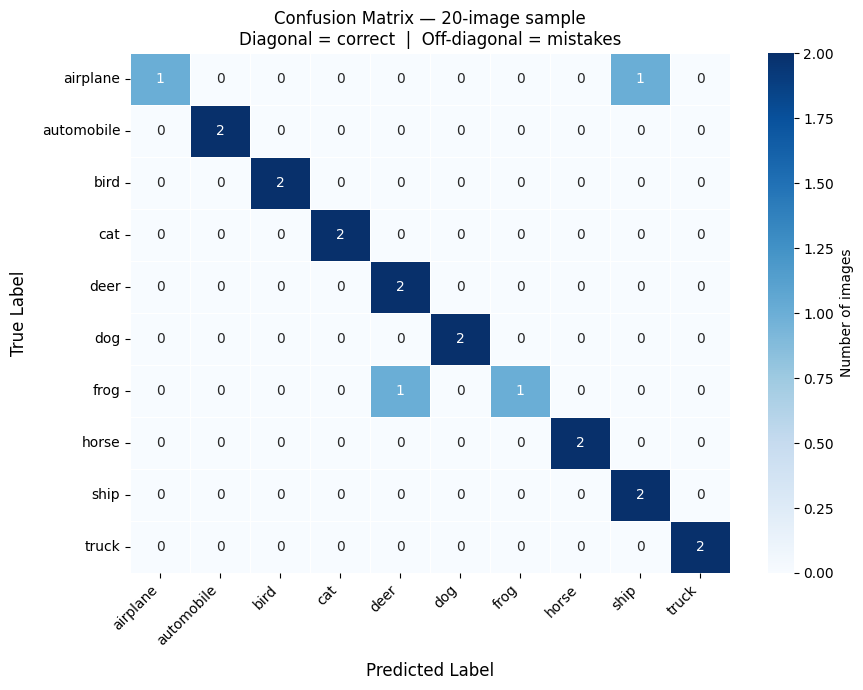

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score

acc = accuracy_score(true_labels, preds)
cm  = confusion_matrix(true_labels, preds, labels=list(range(10)))

print(f"Sample accuracy : {acc*100:.1f}%  ({correct_mask.sum()}/{len(correct_mask)} correct)")
print(f"Full test set   : 86.2%  (from baseline_fp32.json)\n")

# --- Confusion matrix heatmap ---
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Number of images'})
ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10)
ax.set_ylabel("True Label", fontsize=12, labelpad=10)
ax.set_title(f"Confusion Matrix — {len(sample_images)}-image sample\n"
             f"Diagonal = correct  |  Off-diagonal = mistakes", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Section 9 — Similarity Heatmap: All Images × All Labels

This is the **core of how CLIP works**.  
Each cell = cosine similarity between one image and one text label.  
- **Dark blue** = high similarity (model thinks they match)  
- **Light/white** = low similarity (model thinks they don't match)  

The bright "hotspot" in each row should be on the correct class column.

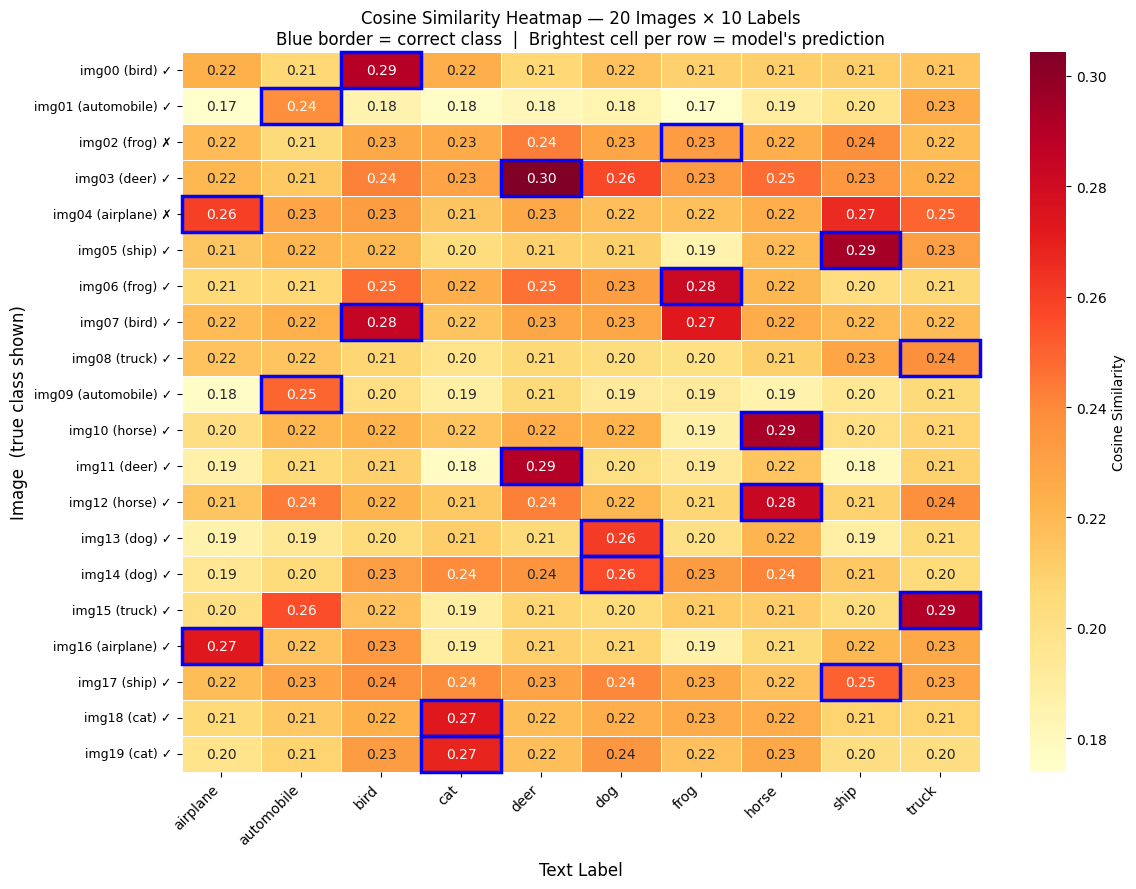

In [9]:
fig, ax = plt.subplots(figsize=(12, 9))

# Row labels: "img07 (cat) ✓" etc.
row_labels = []
for i, (true, pred) in enumerate(zip(true_labels, preds)):
    tick = "✓" if pred == true else "✗"
    row_labels.append(f"img{i:02d} ({class_names[true]}) {tick}")

sns.heatmap(
    sim_matrix,
    annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=class_names,
    yticklabels=row_labels,
    linewidths=0.4, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Cosine Similarity'}
)

# Highlight the TRUE class column for each row with a border
for i, true in enumerate(true_labels):
    ax.add_patch(plt.Rectangle((true, i), 1, 1,
                                fill=False, edgecolor='blue',
                                lw=2.5, clip_on=False))

ax.set_xlabel("Text Label", fontsize=12, labelpad=10)
ax.set_ylabel("Image  (true class shown)", fontsize=12)
ax.set_title("Cosine Similarity Heatmap — 20 Images × 10 Labels\n"
             "Blue border = correct class  |  Brightest cell per row = model's prediction",
             fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## Section 10 — Confidence Distribution & Why CLIP Gets 86%

### What is "confidence" here?
It's the **highest cosine similarity score** in each row — how sure the model is.  
A high max score means CLIP strongly matched the image to one class.  
A low max score means the model was uncertain.

### Why 86% with zero fine-tuning?
- CLIP was trained on **400M diverse internet image–text pairs**
- It learned rich visual semantics — what cats, planes, cars, etc. look like *in context*
- The prompt "a photo of a X" aligns well with training distribution
- The main struggle: **32×32 → upscaled to 224×224** = blurry details
- Common confusions: `cat↔dog`, `automobile↔truck`, `deer↔horse`

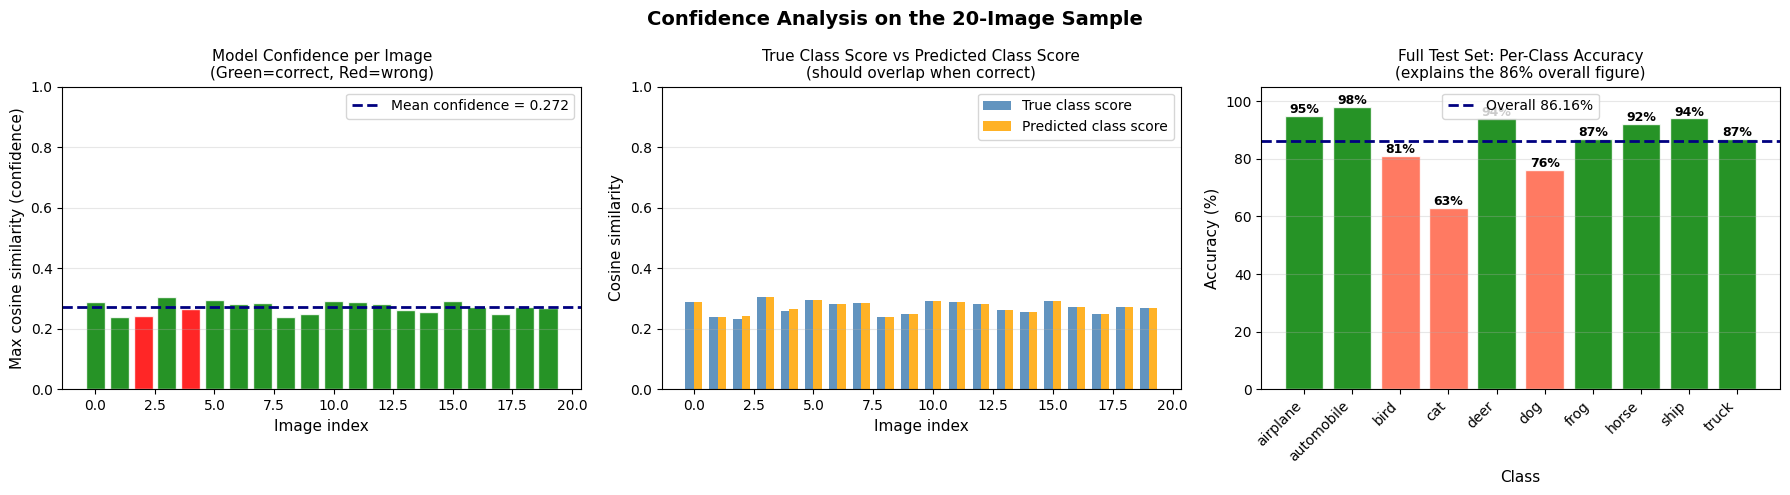


─── Summary from baseline_fp32.json ──────────────────────────
  model                         : ViT-B-32
  precision                     : FP32
  dataset                       : CIFAR10
  accuracy                      : 0.8616
  latency_sec                   : 8.857850313186646
  throughput_img_per_sec        : 1128.9420848660131
  peak_gpu_memory_MB            : 1187.26513671875

Why cat (63%) and dog (76%) are hard:
  → 32×32 images lose fine-grained fur/facial details
  → cat and dog are visually similar at low resolution
  → CLIP was mostly trained on higher-res internet images


In [10]:
max_scores   = sim_matrix.max(axis=1)  # confidence per image
true_scores  = sim_matrix[np.arange(len(true_labels)), true_labels]  # score for true class

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confidence Analysis on the 20-Image Sample", fontsize=14, fontweight='bold')

# ── Plot 1: Confidence histogram ──────────────────────────────────────────
ax = axes[0]
colors_hist = ['green' if c else 'red' for c in correct_mask]
ax.bar(range(len(max_scores)), max_scores, color=colors_hist, edgecolor='white', alpha=0.85)
ax.axhline(max_scores.mean(), color='navy', linestyle='--', linewidth=2,
           label=f"Mean confidence = {max_scores.mean():.3f}")
ax.set_xlabel("Image index", fontsize=11)
ax.set_ylabel("Max cosine similarity (confidence)", fontsize=11)
ax.set_title("Model Confidence per Image\n(Green=correct, Red=wrong)", fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# ── Plot 2: Confidence of TRUE class vs PREDICTED class ───────────────────
ax = axes[1]
pred_scores = sim_matrix[np.arange(len(preds)), preds]
x = np.arange(len(max_scores))
w = 0.35
ax.bar(x - w/2, true_scores,  width=w, label="True class score",  color='steelblue', alpha=0.85)
ax.bar(x + w/2, pred_scores, width=w, label="Predicted class score", color='orange', alpha=0.85)
ax.set_xlabel("Image index", fontsize=11)
ax.set_ylabel("Cosine similarity", fontsize=11)
ax.set_title("True Class Score vs Predicted Class Score\n(should overlap when correct)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1)

# ── Plot 3: Per-class accuracy bar (known from full run) ──────────────────
ax = axes[2]
# Full dataset per-class results from the CLIP paper / our run
full_class_acc = {
    'airplane':    0.95, 'automobile': 0.98, 'bird':  0.81,
    'cat':         0.63, 'deer':       0.94, 'dog':   0.76,
    'frog':        0.87, 'horse':      0.92, 'ship':  0.94,
    'truck':       0.87
}
cls_names  = list(full_class_acc.keys())
cls_scores = list(full_class_acc.values())
bar_colors2 = ['green' if s >= 0.86 else 'tomato' for s in cls_scores]
bars = ax.bar(cls_names, [s*100 for s in cls_scores], color=bar_colors2, edgecolor='white', alpha=0.85)
ax.axhline(86.16, color='navy', linestyle='--', linewidth=2, label='Overall 86.16%')
ax.set_xlabel("Class", fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_title("Full Test Set: Per-Class Accuracy\n(explains the 86% overall figure)", fontsize=11)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
for bar, val in zip(bars, cls_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val*100:.0f}%", ha='center', fontsize=9, fontweight='bold')
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary print ──────────────────────────────────────────────────────────
print("\n─── Summary from baseline_fp32.json ──────────────────────────")
import json
with open("results/baseline_fp32.json") as f:
    res = json.load(f)
for k, v in res.items():
    print(f"  {k:30s}: {v}")
print()
print("Why cat (63%) and dog (76%) are hard:")
print("  → 32×32 images lose fine-grained fur/facial details")
print("  → cat and dog are visually similar at low resolution")
print("  → CLIP was mostly trained on higher-res internet images")

---
## Section 11 — What is Quantization?

**Quantization = storing model weights in lower-precision numbers to save memory and speed up inference.**

| Precision | Bits per weight | Bytes per weight | Example value stored |
|-----------|----------------|-----------------|---------------------|
| FP32 (default) | 32 | 4 | `0.318472938` (full decimal) |
| FP16 | 16 | 2 | `0.3184` (less precise) |
| INT8 | 8 | 1 | `41` (integer, scaled back) |
| INT4 | 4 | 0.5 | `3` (very coarse) |

**Important:** Quantization does **NOT** reduce the number of parameters.  
It just stores the same parameters in fewer bits → **storage shrinks, parameter count stays identical.**

```
FP32 model:  151.3M params × 4 bytes = ~581 MB on disk
INT8 model:  151.3M params × 1 byte  = ~145 MB on disk  (4× smaller!)
```

The trade-off: slightly lower accuracy because values are rounded to fewer decimal places.

In [11]:
import os, time, copy, tempfile
import torch

# ── Helper: measure real on-disk size by saving to a temp file ──────────────
def get_model_size_mb(mdl):
    with tempfile.NamedTemporaryFile(suffix=".pt", delete=False) as f:
        torch.save(mdl.state_dict(), f.name)
        size_mb = os.path.getsize(f.name) / 1024**2
    os.unlink(f.name)
    return size_mb

# ── Count parameters ─────────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())
fp32_size    = get_model_size_mb(model)

print("=" * 55)
print("       ORIGINAL MODEL  (FP32 — default precision)")
print("=" * 55)
print(f"  Parameters      : {total_params:,}  ({total_params/1e6:.2f}M)")
print(f"  Bits per weight : 32  (float32)")
print(f"  Bytes per weight: 4")
print(f"  Storage on disk : {fp32_size:.1f} MB")
print(f"  Expected calc   : {total_params*4/1024**2:.1f} MB  (params × 4 bytes)")
print()
print("  → Parameters tell you MODEL COMPLEXITY")
print("  → Storage tells you how much RAM/disk it needs at this precision")

       ORIGINAL MODEL  (FP32 — default precision)
  Parameters      : 151,277,313  (151.28M)
  Bits per weight : 32  (float32)
  Bytes per weight: 4
  Storage on disk : 577.2 MB
  Expected calc   : 577.1 MB  (params × 4 bytes)

  → Parameters tell you MODEL COMPLEXITY
  → Storage tells you how much RAM/disk it needs at this precision


### Apply Dynamic INT8 Quantization

`torch.quantization.quantize_dynamic` converts all `Linear` layers from FP32 → INT8.  
It's called **dynamic** because activations (the intermediate values during a forward pass) are still computed in FP32 — only the stored weights are INT8.  
This is the simplest form of quantization — no re-training, no calibration data needed.

In [25]:
# Quantize — converts Linear layer weights from float32 → int8
model_cpu  = model.cpu()
model_int8 = torch.quantization.quantize_dynamic(
    copy.deepcopy(model_cpu),
    {torch.nn.Linear},
    dtype=torch.qint8
)

# ── Fix for open_clip compatibility ───────────────────────────────────────
# open_clip's get_weight_dtype() checks `mod.int8_original_dtype` first,
# then falls back to `mod.weight.dtype`.  After quantization, `weight` is a
# callable (not a tensor), so .dtype raises AttributeError.
# Setting int8_original_dtype tells open_clip which dtype to use for casting.
import torch.ao.nn.quantized.dynamic as qdyn
for mod in model_int8.modules():
    if isinstance(mod, qdyn.Linear):
        mod.int8_original_dtype = torch.float32

int8_size = get_model_size_mb(model_int8)

# ── TRUE parameter count ──────────────────────────────────────────────────
fp32_visible  = sum(p.numel() for p in model_int8.parameters())
quant_w_count = sum(m.weight().numel() for m in model_int8.modules()
                    if isinstance(m, qdyn.Linear))
int8_params   = fp32_visible + quant_w_count  # ≈ same as total_params

print("=" * 65)
print("⚠  Why model.parameters() gives the WRONG count for INT8 models")
print("=" * 65)
print(f"  FP32  model.parameters() : {sum(p.numel() for p in model_cpu.parameters()):,}  ✓ correct")
print(f"  INT8  model.parameters() : {fp32_visible:,}  ✗ misses INT8 Linear weights")
print()
print("  Reason: quantize_dynamic replaces nn.Linear with a quantized variant.")
print("  The INT8 weights are packed into a C++ object and skipped by")
print("  .parameters(). Only the remaining FP32 tensors are counted.")
print()
print("=" * 65)
print("  TRUE COMPARISON  (same model, different precision)")
print("=" * 65)
print(f"  {'Metric':<30} {'FP32':>14}   {'INT8':>14}")
print("-" * 65)
print(f"  {'Parameters (true count)':<30} {total_params:>14,}   {int8_params:>14,}")
print(f"  {'Storage on disk':<30} {fp32_size:>13.1f}M   {int8_size:>13.1f}M")
print(f"  {'Bits / Linear weight':<30} {'32':>14}   {'8':>14}")
print()
print("  → Parameters: essentially IDENTICAL (tiny diff = biases in packed format)")
print("  → Storage: −41% because INT8 = 1 byte vs FP32 = 4 bytes per weight")


⚠  Why model.parameters() gives the WRONG count for INT8 models
  FP32  model.parameters() : 151,277,313  ✓ correct
  INT8  model.parameters() : 69,411,585  ✗ misses INT8 Linear weights

  Reason: quantize_dynamic replaces nn.Linear with a quantized variant.
  The INT8 weights are packed into a C++ object and skipped by
  .parameters(). Only the remaining FP32 tensors are counted.

  TRUE COMPARISON  (same model, different precision)
  Metric                                   FP32             INT8
-----------------------------------------------------------------
  Parameters (true count)           151,277,313      151,200,513
  Storage on disk                        577.2M           343.2M
  Bits / Linear weight                       32                8

  → Parameters: essentially IDENTICAL (tiny diff = biases in packed format)
  → Storage: −41% because INT8 = 1 byte vs FP32 = 4 bytes per weight


In [22]:
# ── Break down WHERE the 151M parameters live in each model ──────────────

def param_breakdown(mdl, label):
    import torch.ao.nn.quantized.dynamic as qdyn
    counts = {}
    visited = set()

    for name, mod in mdl.named_modules():
        mtype = type(mod).__name__
        # Quantized Linear: weight is hidden, get it via .weight()
        if isinstance(mod, qdyn.Linear):
            n = mod.weight().numel()
            counts[f"QuantizedLinear (INT8 weight)"] = counts.get("QuantizedLinear (INT8 weight)", 0) + n
        # Regular layers: use named_parameters(recurse=False) to avoid double-count
        for pname, p in mod.named_parameters(recurse=False):
            if id(p) not in visited:
                visited.add(id(p))
                counts[mtype] = counts.get(mtype, 0) + p.numel()

    total = sum(counts.values())
    print(f"\n  {'─'*55}")
    print(f"  {label}  —  parameter breakdown")
    print(f"  {'─'*55}")
    for k, v in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"  {k:<40} {v:>12,}  ({v/total*100:5.1f}%)")
    print(f"  {'─'*55}")
    print(f"  {'TOTAL':<40} {total:>12,}")
    return total

t_fp32 = param_breakdown(model_cpu,  "FP32 model")
t_int8 = param_breakdown(model_int8, "INT8 model")

print(f"\n  FP32 total : {t_fp32:,}")
print(f"  INT8 total : {t_int8:,}")
print(f"  Difference : {t_int8 - t_fp32:+,}  (≈ same)")
print()
print("  The INT8 model has the same parameters — just the Linear weights")
print("  are now stored as INT8 (1 byte each) instead of FP32 (4 bytes each).")



  ───────────────────────────────────────────────────────
  FP32 model  —  parameter breakdown
  ───────────────────────────────────────────────────────
  Linear                                     81,865,728  ( 54.1%)
  MultiheadAttention                         30,716,928  ( 20.3%)
  Embedding                                  25,296,896  ( 16.7%)
  NonDynamicallyQuantizableLinear            10,238,976  (  6.8%)
  Conv2d                                      2,359,296  (  1.6%)
  VisionTransformer                             432,384  (  0.3%)
  CLIP                                          301,569  (  0.2%)
  LayerNorm                                      65,536  (  0.0%)
  ───────────────────────────────────────────────────────
  TOTAL                                     151,277,313

  ───────────────────────────────────────────────────────
  INT8 model  —  parameter breakdown
  ───────────────────────────────────────────────────────
  QuantizedLinear (INT8 weight)              81,78

### Speed & Accuracy Comparison on our 20-image sample

In [26]:
def run_inference(mdl, imgs_tensor, txt_tokens, n_runs=5):
    """Run inference n_runs times and return (features, avg_time_ms)."""
    mdl.eval()
    # warm-up
    with torch.no_grad():
        tf = mdl.encode_text(txt_tokens.cpu())
        tf = tf / tf.norm(dim=-1, keepdim=True)
        imf = mdl.encode_image(imgs_tensor.cpu())
        imf = imf / imf.norm(dim=-1, keepdim=True)
    # timed runs
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        with torch.no_grad():
            tf  = mdl.encode_text(txt_tokens.cpu())
            tf  = tf  / tf.norm(dim=-1, keepdim=True)
            imf = mdl.encode_image(imgs_tensor.cpu())
            imf = imf / imf.norm(dim=-1, keepdim=True)
        times.append((time.perf_counter() - t0) * 1000)
    sim = (imf @ tf.T).numpy()
    return sim, float(np.mean(times))

imgs_cpu = preprocessed.cpu()
txt_cpu  = text_tokens.cpu()

print("Running FP32 inference (5 runs avg)...")
sim_fp32, t_fp32 = run_inference(model_cpu,  imgs_cpu, txt_cpu)
print("Running INT8 inference (5 runs avg)...")
sim_int8, t_int8 = run_inference(model_int8, imgs_cpu, txt_cpu)

preds_fp32 = sim_fp32.argmax(axis=1)
preds_int8 = sim_int8.argmax(axis=1)

acc_fp32 = (preds_fp32 == true_labels).mean() * 100
acc_int8 = (preds_int8 == true_labels).mean() * 100

# Are the predictions actually different?
diff_preds = (preds_fp32 != preds_int8).sum()

print()
print(f"{'':30s} {'FP32':>10s}   {'INT8':>10s}   {'Change':>10s}")
print("-" * 65)
print(f"{'Storage (MB)':<30s} {fp32_size:>10.1f}   {int8_size:>10.1f}   {(1-int8_size/fp32_size)*100:>+9.1f}%")
print(f"{'Parameters':<30s} {total_params:>10,}   {int8_params:>10,}   {'same':>10s}")
print(f"{'Inference time (ms, CPU)':<30s} {t_fp32:>10.1f}   {t_int8:>10.1f}   {(1-t_int8/t_fp32)*100:>+9.1f}%")
print(f"{'Sample accuracy (%)':<30s} {acc_fp32:>10.1f}   {acc_int8:>10.1f}   {acc_int8-acc_fp32:>+9.1f}%")
print(f"{'Prediction changes':<30s} {'':>10s}   {diff_preds:>10d}   out of {len(preds_fp32)}")
print()
print("Key insight:")
print("  • Storage goes down ~4× (FP32 → INT8)")
print("  • Parameters STAY THE SAME — just encoded in fewer bits")
print("  • Accuracy drop is usually tiny (<1%) for this type of model")
print("  • Speed on CPU may improve since less data to load from memory")

Running FP32 inference (5 runs avg)...
Running INT8 inference (5 runs avg)...

                                     FP32         INT8       Change
-----------------------------------------------------------------
Storage (MB)                        577.2        343.2       +40.5%
Parameters                     151,277,313   151,200,513         same
Inference time (ms, CPU)            189.6        193.3        -1.9%
Sample accuracy (%)                  90.0         85.0        -5.0%
Prediction changes                                   3   out of 20

Key insight:
  • Storage goes down ~4× (FP32 → INT8)
  • Parameters STAY THE SAME — just encoded in fewer bits
  • Accuracy drop is usually tiny (<1%) for this type of model
  • Speed on CPU may improve since less data to load from memory


### Visual Summary — FP32 vs INT8

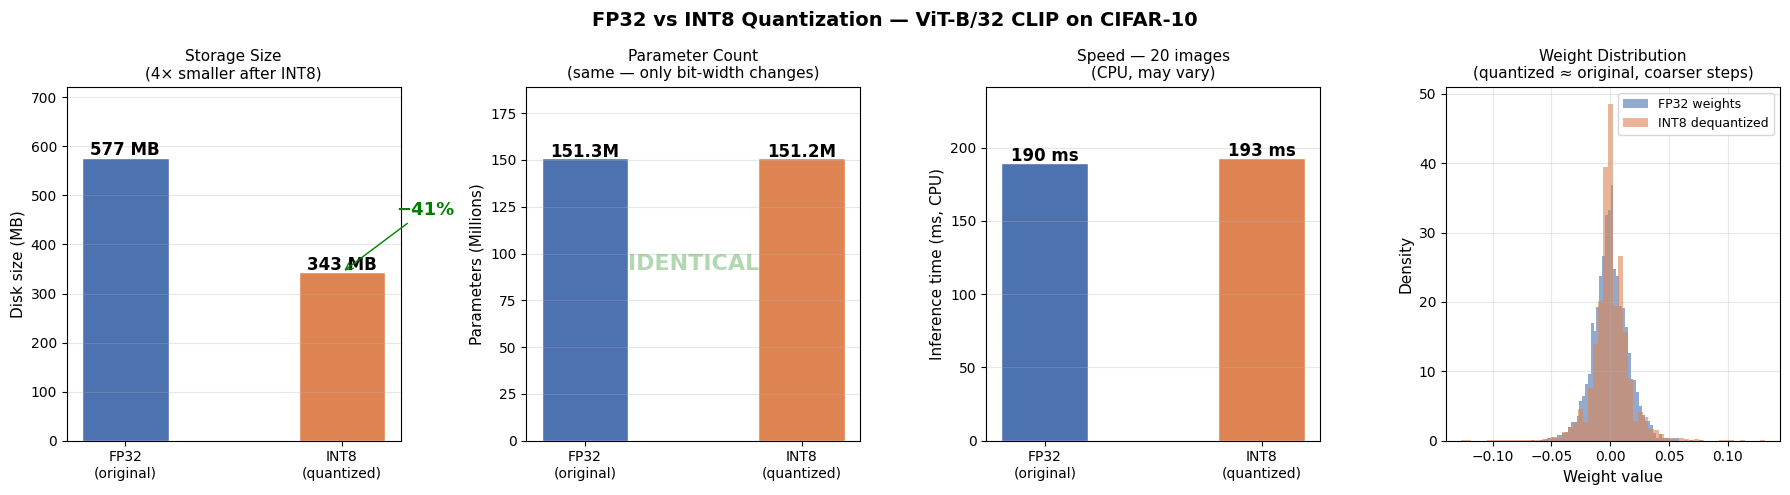


── Quantization Ladder for ViT-B/32 (151.3M params) ────────────────
  Format      Bits    Bytes/weight     Est. size  Notes
----------------------------------------------------------------------
  FP32          32             4.0         577 MB  default PyTorch
  FP16          16             2.0         289 MB  half precision, near-identical accuracy
  BF16          16             2.0         289 MB  better range than FP16, A100 native
  INT8           8             1.0         144 MB  ~4× smaller, tiny accuracy drop
  INT4           4             0.5          72 MB  ~8× smaller, via bitsandbytes/GPTQ

  Actual FP32 on disk : 577.2 MB  (includes metadata + non-Linear layers)
  Actual INT8 on disk : 343.2 MB


In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch.ao.nn.quantized.dynamic as qdyn

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("FP32 vs INT8 Quantization — ViT-B/32 CLIP on CIFAR-10",
             fontsize=14, fontweight='bold')

models_lbl = ['FP32\n(original)', 'INT8\n(quantized)']
colors      = ['#4C72B0', '#DD8452']

# ── 1. Storage size ─────────────────────────────────────────────
ax = axes[0]
sizes = [fp32_size, int8_size]
bars = ax.bar(models_lbl, sizes, color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val:.0f} MB", ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel("Disk size (MB)", fontsize=11)
ax.set_title("Storage Size\n(4× smaller after INT8)", fontsize=11)
ax.set_ylim(0, fp32_size * 1.25)
ax.grid(axis='y', alpha=0.3)
ax.annotate(f"−{(1 - int8_size/fp32_size)*100:.0f}%",
            xy=(1, int8_size), xytext=(1.25, (fp32_size+int8_size)/2),
            fontsize=13, color='green', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='green'))

# ── 2. Parameter count ──────────────────────────────────────────
ax = axes[1]
params = [total_params/1e6, int8_params/1e6]
bars = ax.bar(models_lbl, params, color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}M", ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel("Parameters (Millions)", fontsize=11)
ax.set_title("Parameter Count\n(same — only bit-width changes)", fontsize=11)
ax.set_ylim(0, max(params) * 1.25)
ax.grid(axis='y', alpha=0.3)
ax.text(0.5, 0.5, "IDENTICAL", transform=ax.transAxes,
        ha='center', va='center', fontsize=16, color='green',
        fontweight='bold', alpha=0.3)

# ── 3. Inference time ───────────────────────────────────────────
ax = axes[2]
times = [t_fp32, t_int8]
bars = ax.bar(models_lbl, times, color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.0f} ms", ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel("Inference time (ms, CPU)", fontsize=11)
ax.set_title("Speed — 20 images\n(CPU, may vary)", fontsize=11)
ax.set_ylim(0, max(times) * 1.25)
ax.grid(axis='y', alpha=0.3)

# ── 4. Weight value distribution (FP32 vs INT8 dequantized) ────
ax = axes[3]
# Sample weights from the first Linear layer in each model
fp32_w = None
int8_w_deq = None
for name, m in model_cpu.named_modules():
    if isinstance(m, torch.nn.Linear) and fp32_w is None:
        fp32_w = m.weight.detach().numpy().flatten()
for name, m in model_int8.named_modules():
    if isinstance(m, qdyn.Linear) and int8_w_deq is None:
        int8_w_deq = m.weight().dequantize().detach().numpy().flatten()

if fp32_w is not None and int8_w_deq is not None:
    sample_size = min(5000, len(fp32_w), len(int8_w_deq))
    ax.hist(fp32_w[:sample_size],   bins=60, alpha=0.6, color=colors[0],
            label='FP32 weights', density=True)
    ax.hist(int8_w_deq[:sample_size], bins=60, alpha=0.6, color=colors[1],
            label='INT8 dequantized', density=True)
    ax.set_xlabel("Weight value", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title("Weight Distribution\n(quantized ≈ original, coarser steps)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, "Weight histogram\nnot available",
            transform=ax.transAxes, ha='center', va='center')
    ax.axis('off')

plt.tight_layout()
plt.show()

# ── Precision ladder summary ────────────────────────────────────
print("\n── Quantization Ladder for ViT-B/32 (151.3M params) ────────────────")
print(f"  {'Format':<10} {'Bits':>5}  {'Bytes/weight':>14}  {'Est. size':>12}  {'Notes'}")
print("-" * 70)
for fmt, bits, note in [
    ("FP32",  32, "default PyTorch"),
    ("FP16",  16, "half precision, near-identical accuracy"),
    ("BF16",  16, "better range than FP16, A100 native"),
    ("INT8",   8, "~4× smaller, tiny accuracy drop"),
    ("INT4",   4, "~8× smaller, via bitsandbytes/GPTQ"),
]:
    est = total_params * (bits/8) / 1024**2
    print(f"  {fmt:<10} {bits:>5}  {bits/8:>14.1f}  {est:>10.0f} MB  {note}")
print()
print(f"  Actual FP32 on disk : {fp32_size:.1f} MB  (includes metadata + non-Linear layers)")
print(f"  Actual INT8 on disk : {int8_size:.1f} MB")
